# Student Performance Prediction

## 1. Introduction

Student performances are affected by a lot of things including time spent studying, family support and the health of the students. It is very important to understand which of these contribute the most to a student's performance in order to help educators identify areas where interventions may improve academic performance and student success.

The aim of this project is to analyse student performance dataset, identify the factors that influence students' academic performance and develop machine learning regression models that are able  predict students' final grades. The project follows a complete data science workflow, including data exploration, data cleaning, exploratory data analysis, feature preparation, model training, and model evaluation.

Three regression models were created, namely, Linear Regression, K-Nearest Neighbours Regression, and a Neural Network and compared to determine which model produced the most accurate predictions. Model performance was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

This project was developed as part of my data science portfolio while completing the Postgraduate Diploma in Data Science at the University of the Witwatersrand. It demonstrates practical skills in Python, data analysis, machine learning using scikit-learn, and the communication of data-driven insights.

## 2. Import Libraries

In [35]:
import pandas as pd
import numpy as np 

## 3. Load Dataset

In [36]:
df = pd.read_csv("student_data.csv")

## 4. Data Exploration

In [37]:
# Checking the first 5 rows of the dataset 
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [38]:
# Check the number of rows and columns the dataset has
print(df.shape[0])
print(df.shape[1])

395
33


In [39]:
# Checking the dataset column names
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')


### Column names explanation
school : The school names of the students

sex : student's sex gender

age : student's age

address : student's home address type

famsize : family size ("LE3" - less or equal to 3 and "GT3" - greater than 3)

Pstatus : parent's cohabitation status ("T" - living together and "A" - apart)

Medu : mother's education (0 - none, 1 - up to the 4th grade, 2 - 5th to 9th grade, 3 - secondary education and 4 - higher education)
Fedu : father's education 

Mjob : mother's job 

Fjob : father's job 

reason : reason to choose this school 

guardian : student's guardian 

traveltime : home to school travel time (1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)

studytime : weekly study time (1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)

failures : number of past class failures 

schoolsup : extra educational support 

famsup : family educational support 

paid : extra paid classes

activities : extracurricular activities 

nursery : attended nursery school 

higher : whether student wants to take higher education 

internet : Internet access at home 

romantic : with a romantic relationship 

famrel : quality of family relationships ( 1 - very bad to 5 - excellent)

freetime : free time after school (1 - very low to 5 - very high)

goout : going out with friends (1 - very low to 5 - very high)

Dalc : workday alcohol consumption (1 - very low to 5 - very high)

Walc : weekend alcohol consumption (1 - very low to 5 - very high)

health : current health status (1 - very bad to 5 - very good)

absences : number of school absences

In [40]:
#data types
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [41]:
#
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


The Student Performance dataset was explored to understand its structure and identify the different types of variables in the dataset.
The dataset consists of 395 student records and 33 variables, with G3 (final grade) selected as the target variable to be predicted.

The dataset was examined using functions such as df.head(), df.dtypes, dy.info and df.describe(). These functions were used to examine the first few records, identify the data types of each variable, to check for missing values and obtain summary statistics for the numerical features

The dataset contained both numerical and categorical variables. Numerical variables included features such as age, study time, absences, first grades, and second grades, while categorical variables included school, sex, address, parental jobs, internet access, and participation in extracurricular activities.

The dataset was checked for missing values and no missing data were found. This meant that no data imputation or removal of incomplete records was required. The data types of all variables were verified to ensure that numerical and categorical features were correctly identified. Descriptive statistics were generated for the numerical variables to understand their distributions. Variables such as studytime and health had relatively small ranges, while absences showed greater variability among students.

The exploration process confirmed that the dataset was complete, contained a mixture of numerical and categorical variables, and was suitable for building regression models to predict students' final grades.



## 5. Data Cleaning

In [42]:
# Checking for missing values
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [43]:
# Checking for duplicate rows
print(df.duplicated().sum())

0


In [44]:
# Counting important categories
print("Unique School Values")
print(df.school.unique())
print()
print("Unique Genders")
print(df.sex.unique())
print()
print("Unique Addresses")
print(df.address.unique())
print()
print("Unique Family Sizes")
print(df.famsize.unique())
print()
print("Unique Parent Stastus")
print(df.Pstatus.unique())
print()
print("Unique Mothers' jobs")
print(df.Mjob.unique())
print()
print("Unique Fathers' jobs")
print(df.Fjob.unique())
print()
print("Unique Reasons")
print(df.reason.unique())
print()
print("Unique Guardians")
print(df.guardian.unique())
print()
print("Unique School Support Values")
print(df.schoolsup.unique())
print()
print("Unique Family Support Values")
print(df.famsup.unique())
print()
print("Unique Pays")
print(df.paid.unique())
print()
print("Unique Extracurricular Activities")
print(df.activities.unique())
print()
print("Unique Higher Education Status")
print(df.higher.unique())
print()
print("Unique Relationship Status")
print(df.romantic.unique())
print()
print("Unique Internet Access Values")
print(df.internet.unique())
print()
print("Unique Nursery Status")
print(df.nursery.unique())
print()

Unique School Values
<StringArray>
['GP', 'MS']
Length: 2, dtype: str

Unique Genders


<StringArray>
['F', 'M']
Length: 2, dtype: str

Unique Addresses
<StringArray>
['U', 'R']
Length: 2, dtype: str

Unique Family Sizes
<StringArray>
['GT3', 'LE3']
Length: 2, dtype: str

Unique Parent Stastus
<StringArray>
['A', 'T']
Length: 2, dtype: str

Unique Mothers' jobs
<StringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str

Unique Fathers' jobs
<StringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str

Unique Reasons
<StringArray>
['course', 'other', 'home', 'reputation']
Length: 4, dtype: str

Unique Guardians
<StringArray>
['mother', 'father', 'other']
Length: 3, dtype: str

Unique School Support Values
<StringArray>
['yes', 'no']
Length: 2, dtype: str

Unique Family Support Values
<StringArray>
['no', 'yes']
Length: 2, dtype: str

Unique Pays
<StringArray>
['no', 'yes']
Length: 2, dtype: str

Unique Extracurricular Activities
<StringArray>
['no', 'yes']
Length: 2, dtype: str

Unique Higher Education Status
<Str

Before evaluating the relationship between the features and the target variable (G3), the dataset was checked for missing values and duplicates using df.isnull().sum() and df.duplicated().sum(). This showed that the dataset had no missing values and no duplicates, therefore no data cleaning was required. 

The amount of values for the categorical features were cThe frequency of each categorical feature was examined to identify any inconsistencies or invalid values. The value counts for all categorical features were as expected, indicating no corrections or data cleaning were required.

The dataset was therefore considered clean and suitable for further analysis and model development.

## 6. Visualisations

### Is the dataset gender evenly distributed?

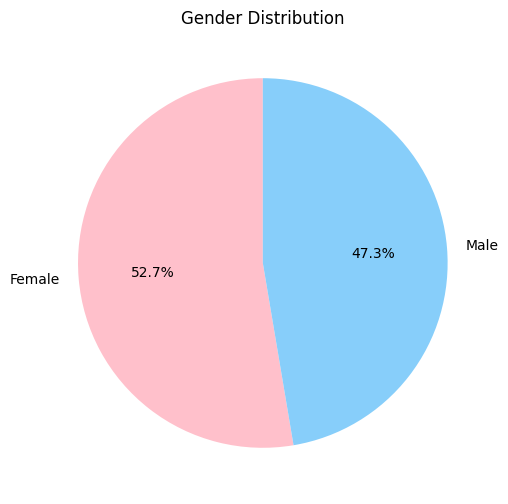

In [45]:
import matplotlib.pyplot as plt

gender_counts = df["sex"].value_counts()

gender_counts = df["sex"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    gender_counts,
    labels=["Female", "Male"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["pink", "lightskyblue"] 
)

plt.title("Gender Distribution")
plt.show()

The gender distribution in the dataset appears to be relatively balanced since there are 52.7% females and 47.3% males. 

### Are there more passes or fails?

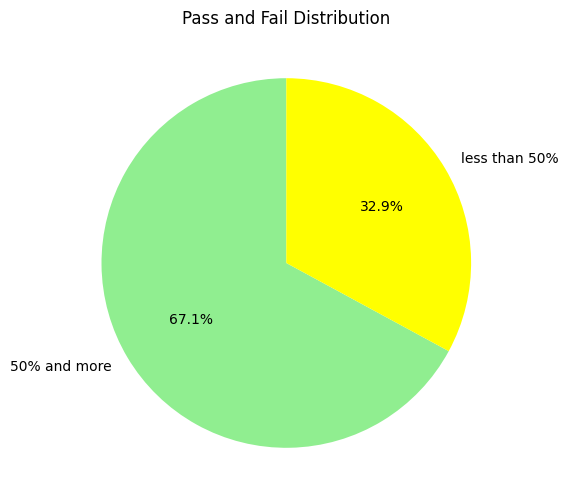

In [46]:
# Separating the students by the marks they achieved
results = []

for mark in df["G3"]:
    if mark < 10:
        results.append("less than 50%")

    else:
        results.append("50% and more")

df["Results"] = results


# Creating the pie chart
result_counts = df["Results"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    result_counts,
    labels=result_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightgreen", "yellow"]   # Choose your own colours
)

plt.title("Pass and Fail Distribution")
plt.show()

del df["Results"]

The pass/fail distribution indicates that the overall performance of the students is satisfactory, with the majority achieving a final grade of 50% or above.

### Do Males or Females perform better?

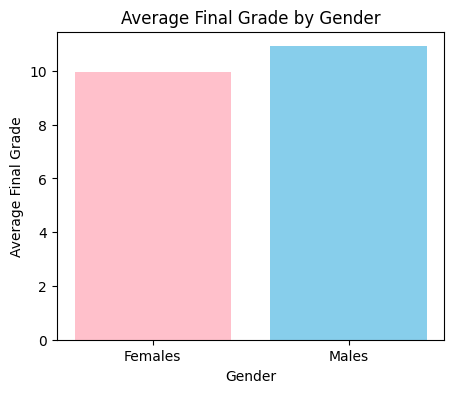

In [47]:
# Calculating the final grade averages of males and females
grades_sum = dict()

males = []
females = []
for i in range(len(df)):
    sex = df["sex"][i]
    grades = df["G3"][i]

    if sex in grades_sum:
        grades_sum[sex] += grades

    else: 
        grades_sum[sex] = grades

    if sex == "M":
        males.append("M")

    elif sex == "F":
        females.append("F")

for gender, total in grades_sum.items():
    if gender == "F":
        average_female = total / len(females)

    elif gender == "M":
        average_male = total / len(males)

# Creating a bar graph
plt.figure(figsize=(5,4))
plt.bar(["Females", "Males"],[average_female, average_male],color=["pink", "skyblue"])
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Gender")
plt.show()

The average final grade for male students is slightly higher than that of female students. However, the difference is relatively small. This then that both gender perform similarly. 

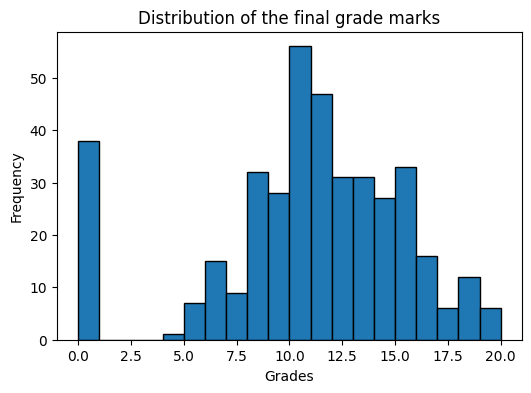

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["G3"], bins=20, edgecolor="black")
plt.xlabel("Grades")
plt.ylabel("Frequency")
plt.title("Distribution of the final grade marks")
plt.show()

The distribution is not perfectly symmetric due to the large number of zero grades. It is also noticable that very few students achieved the highest grades (18–20), indicating that exceptional performance was relatively uncommon.

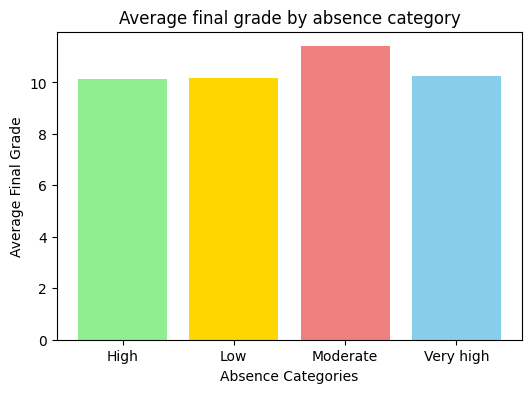

In [49]:
# Categorizing absences
absence_categories = []
for i in range(len(df)):
    num_absences = df["absences"][i]

    if num_absences <= 5:
        absence_categories.append("Low")
    
    elif  6 <= num_absences <= 10:
        absence_categories.append("Moderate")

    elif 11 <= num_absences <= 20:
        absence_categories.append("High")

    else:
        absence_categories.append("Very high")
df["Absence Category"] = absence_categories
average_grade = df.groupby("Absence Category")["G3"].mean()

# create a bar graph
plt.figure(figsize=(6,4))

plt.bar(
    average_grade.index,
    average_grade.values,
    color=["lightgreen", "gold", "lightcoral", "skyblue"]
)

plt.xlabel("Absence Categories")
plt.ylabel("Average Final Grade")
plt.title("Average final grade by absence category")

plt.show()
del df["Absence Category"]

The average final grades were similar across the different absence categories, suggesting that the number of days absent had little observable influence on students' academic performance.

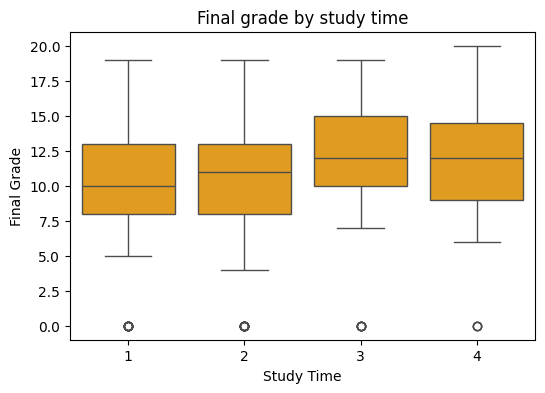

In [50]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="studytime", y="G3",color= "orange", data=df)
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Final grade by study time")
plt.show()

The median final grade increases as study time increases, suggesting that students who spend more time studying generally achieve higher grades. Although there is variation within each category, the overall trend indicates a positive relationship between study time and academic performance.

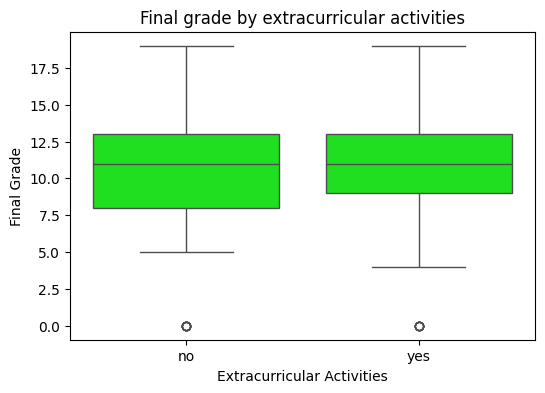

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x="activities", y="G2", data=df, color= "lime")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Final Grade")
plt.title("Final grade by extracurricular activities")
plt.show()

The median final grades of students that participate extracurricular activities is the same as the students that don't participate, suggesting that extracurricular activities are not strongly associated with academic performance.

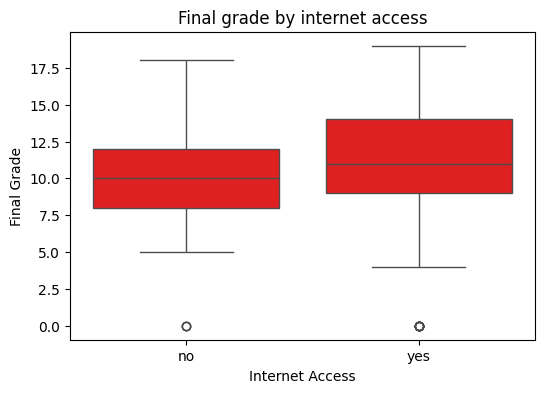

In [52]:
plt.figure(figsize=(6,4))
sns.boxplot(x="internet", y="G2", data=df, color= "red")
plt.xlabel("Internet Access")
plt.ylabel("Final Grade")
plt.title("Final grade by internet access")
plt.show()

The median final grade of the students who have internet access is higher which suggests that students who have internet access perform better academically. 

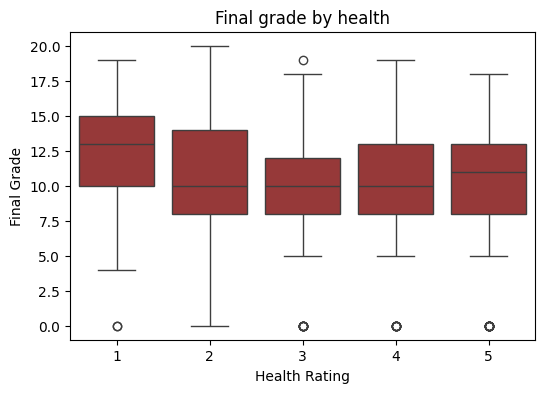

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(x="health", y="G3", data=df, color= "brown")
plt.xlabel("Health Rating")
plt.ylabel("Final Grade")
plt.title("Final grade by health")
plt.show()

There is no consistent trend in health rating and academic performance. This suggests that health rating does not have a strong relationship with students' final grades in this dataset.

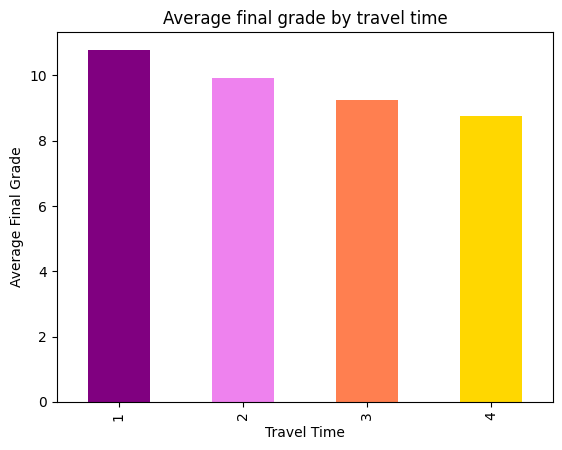

In [54]:
avg = df.groupby("traveltime")["G3"].mean()

avg.plot(kind="bar", color=["purple", "violet", "coral", "gold"])
plt.xlabel("Travel Time")
plt.ylabel("Average Final Grade")
plt.title("Average final grade by travel time")
plt.show()

It is noticeable that students who live closer to the school generally have higher final grades than those who live farther away. This suggests an association between living closer to the school and higher academic performance.

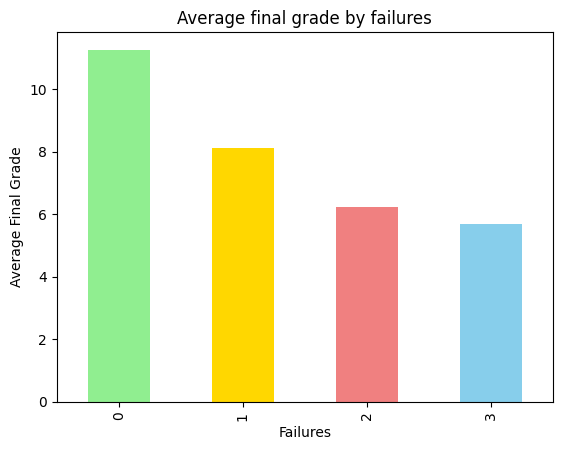

In [55]:
avg = df.groupby("failures")["G3"].mean()

avg.plot(kind="bar", color= ["lightgreen", "gold", "lightcoral", "skyblue"])
plt.xlabel("Failures")
plt.ylabel("Average Final Grade")
plt.title("Average final grade by failures")
plt.show()

The bar graph shows that students that have more failures tend to have lower final grades than students who have less failures. This further shows that student performance is affected by pervious academic performance.  

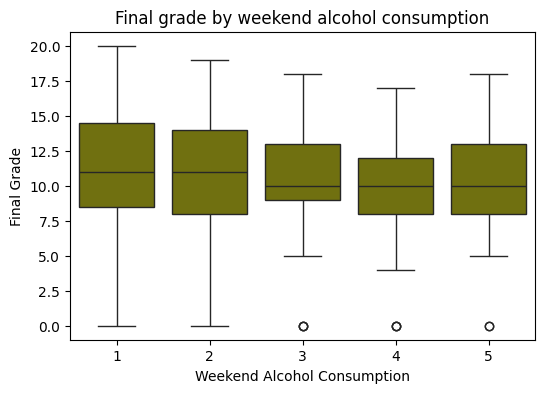

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Walc", y="G3", data=df, color= "olive")
plt.xlabel("Weekend Alcohol Consumption")
plt.ylabel("Final Grade")
plt.title("Final grade by weekend alcohol consumption")
plt.show()

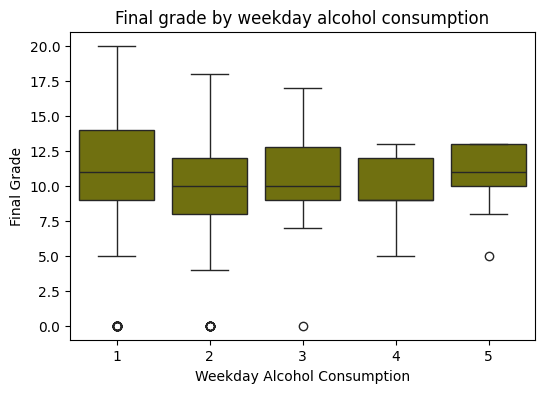

In [57]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Dalc", y="G3", data=df, color= "olive")
plt.xlabel("Weekday Alcohol Consumption")
plt.ylabel("Final Grade")
plt.title("Final grade by weekday alcohol consumption")
plt.show()

The median final grades are fairly similar across all levels of weekend and weekday alcohol consumption and also there is no trend in the spread of the grades. This suggests that alcohol consumption does not have a strong relationship with students' final grades.

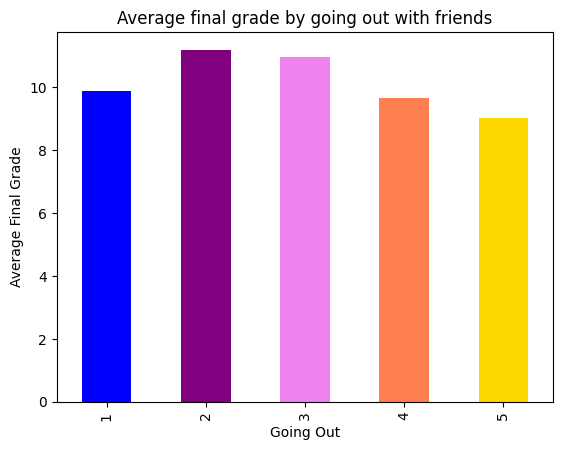

In [58]:
avg = df.groupby("goout")["G3"].mean()

avg.plot(kind="bar", color=["blue", "purple", "violet", "coral", "gold"])
plt.xlabel("Going Out")
plt.ylabel("Average Final Grade")
plt.title("Average final grade by going out with friends")
plt.show()

The bar graph shows no increasing or decreasing grade trend in relation to students going out with friends. This indicates that going out with friends has no strong relationship with academic performance.

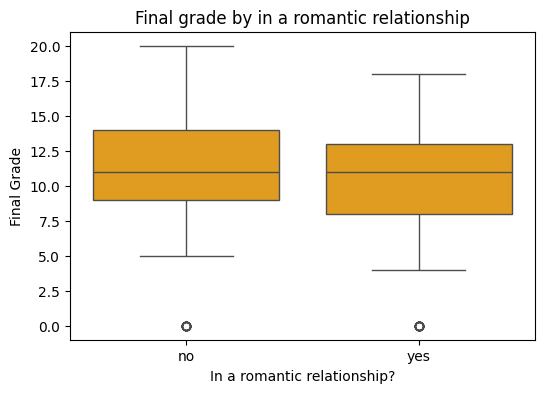

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x="romantic", y="G3", data=df, color= "orange")
plt.xlabel("In a romantic relationship?")
plt.ylabel("Final Grade")
plt.title("Final grade by in a romantic relationship")
plt.show()

The median final grades of students in a romantic relationship and those who are not appear to be similar, suggesting that there is no strong relationship between student having romantic relationships and academic performance

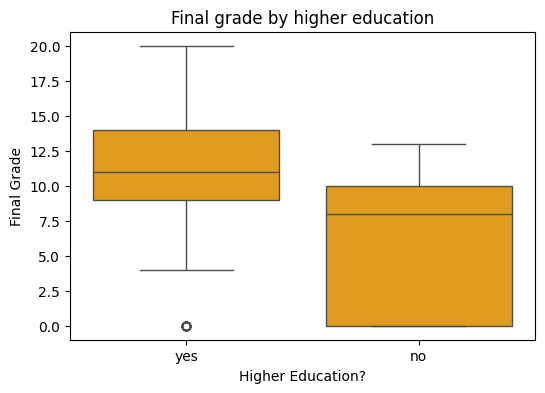

In [60]:
plt.figure(figsize=(6,4))
sns.boxplot(x="higher", y="G3", data=df, color= "orange")
plt.xlabel("Higher Education?")
plt.ylabel("Final Grade")
plt.title("Final grade by higher education")
plt.show()

The students that want to pursue higher education performance well academically than those who do not want to. This shows that wanting to pursue higher education has an influence in the students' academic performance. 

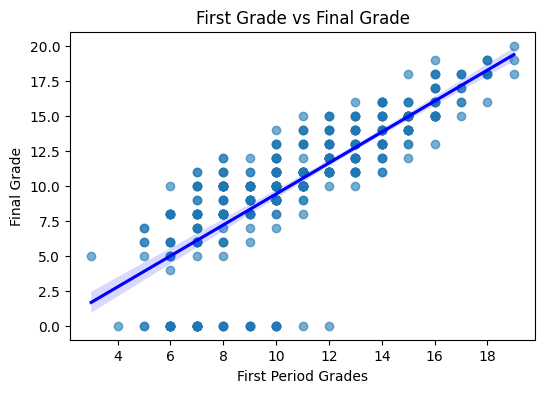

In [61]:
plt.figure(figsize=(6,4))
sns.regplot(x="G1", y="G3", data=df, scatter_kws={"alpha":0.6}, line_kws= {"color":"blue"})
plt.xlabel("First Period Grades")
plt.ylabel("Final Grade")
plt.title("First Grade vs Final Grade")
plt.show()

It appears that students that achieved high grades in the first-period generally achieved high final grades. This indicates that previous academic performance are strongly related to the final grade. 

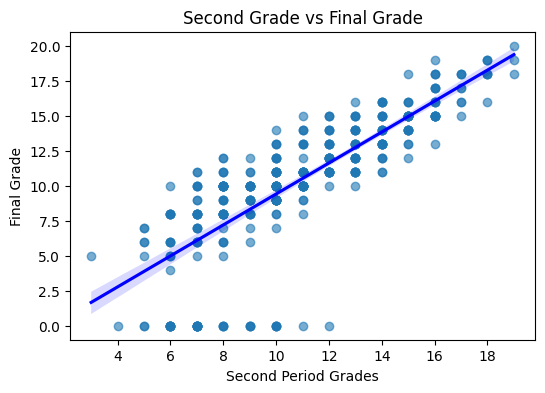

In [62]:
plt.figure(figsize=(6,4))
sns.regplot(x="G1", y="G3", data=df, scatter_kws={"alpha":0.6}, line_kws= {"color":"blue"})
plt.xlabel("Second Period Grades")
plt.ylabel("Final Grade")
plt.title("Second Grade vs Final Grade")
plt.show()


The scatter plot shows that student with high second grades also achieved high final grades. This further iterates that previous academic performances are strongly related to final grades. 

## 7. Feature Preparation

In [63]:
# Inputs and target
X = df.drop("G3", axis=1)
y = df["G3"]

# One-hot encoding the categorical features
categorical_columns = ["famsize", "school", "sex", "address", "Pstatus", "Mjob", "Fjob", "reason", "guardian", "schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]
X = pd.get_dummies(X, columns= categorical_columns, dtype=int)
print(X.head())

# For future normalization 
numeric_columns = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences", "G1", "G2"]

   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  activities_no  activities_yes  nursery_no  nursery_yes  \
0     1  ...              1               0           0            1   
1     1  ...              1               0           1            0   
2     2  ...              1               0           0            1   
3     1  ...              0               1           0            1   
4     1  ...              1               0           0            1   

   higher_no  higher_yes  internet_no  internet_yes  romantic_no  romantic_yes  
0    

The dataset was prepared for regression modelling by separating the predictor variables from the target variable. The G3 (final grade) feature was selected as the target variable (y), while all remaining variables were used as the predictor variables (X).



## 8. Train/Test Split

In [64]:
# 20% Testing and 80% training
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 50 
)

# Normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

For the training and testing dataset split, the dataset was divided into training and testing sets using an 80:20 split. The training set was used to train the machine learning models, while the testing set was reserved for evaluating their performance on unseen data.

The numerical features were normalised using Min-Max scaling, which transformed their values to a range between 0 and 1. Normalisation ensured that features measured on different scales contributed more equally during model training. 

## 9. Model Building

In [75]:
# Linear Regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


# Neural Network Regression Model
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(80, ), 
    solver="adam",
    max_iter=500,
    early_stopping=True,
    random_state=50
)
mlp.fit(X_train, y_train)


# K-Nearest Neighbours Regression Model
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train, y_train)

#Random Forest Regression Model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=95,
    random_state=50
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",95
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

The three regression models developed to predict students' final grades (G3) were: Linear Regression, K-Nearest Neighbours Regression, and a Neural Network (MLP Regressor).

Each model was trained in the same way and using the same prepared training dataset to ensure a fair comparison

## 10. Model Evaluation

In [76]:
# Regression evaluations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression model evaluation
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Mean Absolute Error for the Linear Model:", round(mae_lr, 3))
print("Mean Squared Error for the Linear Model:", round(mse_lr, 3))
print("Root Mean Squared Error for the Linear Model:", round(rmse_lr, 3))
print("R-Squared for the Linear Model:", round(r2_lr, 3))
print()


# Neural Network Regression Model evaluation
y_pred_mlp = mlp.predict(X_test)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("Mean Absolute Error for the Neural Network Model:", round(mae_mlp, 3))
print("Mean Squared Error for the Neural Network Model:", round(mse_mlp, 3))
print("Root Mean Squared Error for the Neural Network Model:", round(rmse_mlp, 3))
print("R-Squared:", round(r2_mlp, 3))
print()


# K-Nearest Neighbours Regression Model evaluation
y_pred_knn = knn.predict(X_test)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)


print("Mean Absolute Error for K-Nearnest Neighbours Model:", round(mae_knn, 3))
print("Mean Squared Error for K-Nearnest Neighbours Model:", round(mse_knn, 3))
print("Root Mean Squared Error for K-Nearnest Neighbours Model:", round(rmse_knn, 3))
print("R-Squared for K-Nearnest Neighbours Model:", round(r2_knn, 3))

# Decision Tress Model Evaluation
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print()

print("Mean Absolute Error for Decision Tree Model:", round(mae_rf, 3))
print("Mean Squared Error for Decision Tree Model:", round(mse_rf, 3))
print("Root Mean Squared Error for Decision Tree Model:", round(rmse_rf, 3))
print("R-Squared for Decision Tree Model:", round(r2_rf, 3))


Mean Absolute Error for the Linear Model: 1.334
Mean Squared Error for the Linear Model: 3.381
Root Mean Squared Error for the Linear Model: 1.839
R-Squared for the Linear Model: 0.853

Mean Absolute Error for the Neural Network Model: 3.706
Mean Squared Error for the Neural Network Model: 22.202
Root Mean Squared Error for the Neural Network Model: 4.712
R-Squared: 0.035

Mean Absolute Error for K-Nearnest Neighbours Model: 3.42
Mean Squared Error for K-Nearnest Neighbours Model: 20.599
Root Mean Squared Error for K-Nearnest Neighbours Model: 4.539
R-Squared for K-Nearnest Neighbours Model: 0.105

Mean Absolute Error for Decision Tree Model: 0.88
Mean Squared Error for Decision Tree Model: 1.75
Root Mean Squared Error for Decision Tree Model: 1.323
R-Squared for Decision Tree Model: 0.924


Once training was complete, the models were used to predict the final grades of students in the testing dataset. These predictions were then evaluated using regression performance metrics to determine which model produced the most accurate predictions. Among the three models evaluated, the Decision Tree Regressor achieved the best performance with an MAE of 0.88, an RMSE of 1.323, and an R² score of 0.924. This indicates that the model explained approximately 92% of the variation in students' final grades while maintaining the lowest prediction error. The Linear Regression also produced good results but had slightly higher errors while the K-Nearest Neighbors and Neural Network performed poorly KNN performed worse than the other models.

## 11. Conclusion

This project applied a complete data science workflow to predict students' final grades using the Student Performance dataset. The workflow included data exploration, data cleaning, visualisation, feature preparation, model building, and model evaluation.

The visualisations showed that study time, travel time from home to school, number of failures, wanting to pursue higher eduction and previous academic performances are the influencing factors in student performance. 

The machine learning models were evaluated using regression metrics, including Mean Absolute Error, Mean Squared Error, Root Mean Squared Error, and the R-square score. Among the models evaluated, the Decision Tree Regressor achieved the best overall performance, producing the most accurate predictions on the test data.

Overall, the project was a successful in evaluating the dataset, identifying the factors that influence student performance and developing a machine learning model capable of predicting students' final grades with good accuracy. 

## 12. Recommendations

Future work could investigate additional regression algorithms, such as Random Forest Regression, to determine whether they improve prediction performance. 

Further analysis can be done to identify which factors afffect student performance the most. Another way to improve student performance predictions is to collect a more recent dataset. 